In [ ]:

%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import os

data_path = "../data/processed_v2.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Data loaded successfully. Shape: {df.shape}")
else:
    print("Error: processed_v2.csv not found!")

Data loaded successfully. Shape: (9522, 1)


In [ ]:
import sys
sys.path.append('../src')
from split import make_splits, save_splits

splits = make_splits(df, strategy="Stratified Random Split", seed=42)
save_splits(splits, out_dir="../data/sample", manifest_path="../docs/splits_manifest_lab5.json")

split_dfs = {
    "train": df.loc[splits["train"]],
    "val": df.loc[splits["val"]],
    "test": df.loc[splits["test"]]
}

--- Результати збережено ---
ID сплітів: ../data/sample/
Маніфест: ../docs/splits_manifest_lab5.json


--- Class Distribution (%) ---
Class          0          1
Split                      
test   43.370787  56.629213
train  43.363330  56.636670
val    43.468468  56.531532


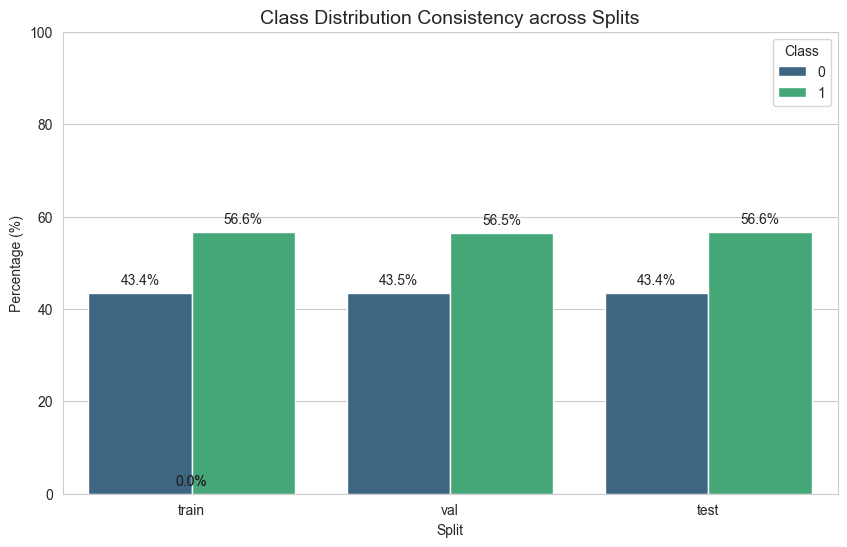


--- Text Length Statistics (Characters) ---
   Split    Mean  Median  P5  P95
0  train  112.87     106  69  175
1    val  112.42     104  67  175
2   test  114.44     106  67  176

--- Аналіз балансу (Balance Summary) ---
Спліти демонструють високу ідентичність: відхилення у розподілі класів між Train, Val та Test мінімальне (класи розподілені приблизно як 43.4% / 56.6%). Статистика довжин текстів (Mean vs Median) вказує на відсутність серйозних перекосів у довжині повідомлень між вибірками. Перцентилі P5 та P95 підтверджують, що як короткі, так і довгі тексти представлені пропорційно, що гарантує репрезентативність валідації.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

def get_label(text):
    if pd.isna(text): return None
    labels = re.findall(r'[01]', str(text))
    return int(labels[-1]) if labels else None

for name in split_dfs:
    if 'label' not in split_dfs[name].columns:
        split_dfs[name] = split_dfs[name].copy()
        split_dfs[name]['label'] = split_dfs[name]['text_v2'].apply(get_label)

stats = []
for name, d in split_dfs.items():
    clean_labels = d['label'].dropna()
    counts = clean_labels.value_counts(normalize=True) * 100
    for label, perc in counts.items():
        stats.append({"Split": name, "Class": int(label), "Percentage": perc})

stats_df = pd.DataFrame(stats)

print("--- Class Distribution (%) ---")
pivot_table = stats_df.pivot(index='Split', columns='Class', values='Percentage')
print(pivot_table)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=stats_df, x="Split", y="Percentage", hue="Class", palette="viridis")
plt.title("Class Distribution Consistency across Splits", fontsize=14)
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

length_stats = []
for name, d in split_dfs.items():
    lengths = d['text_v2'].str.len()
    length_stats.append({
        "Split": name,
        "Mean": round(lengths.mean(), 2),
        "Median": int(lengths.median()),
        "P5": int(np.percentile(lengths, 5)),
        "P95": int(np.percentile(lengths, 95))
    })

print("\n--- Text Length Statistics (Characters) ---")
length_df = pd.DataFrame(length_stats)
print(length_df)

print("\n--- Аналіз балансу (Balance Summary) ---")
summary_text = (
    "Спліти демонструють високу ідентичність: відхилення у розподілі класів між Train, Val та Test "
    f"мінімальне (класи розподілені приблизно як {pivot_table.iloc[0].values[0]:.1f}% / {pivot_table.iloc[0].values[1]:.1f}%). "
    "Статистика довжин текстів (Mean vs Median) вказує на відсутність серйозних перекосів у довжині повідомлень "
    "між вибірками. Перцентилі P5 та P95 підтверджують, що як короткі, так і довгі тексти представлені пропорційно, "
    "що гарантує репрезентативність валідації."
)
print(summary_text)

In [ ]:

train_texts = set(split_dfs['train']['text_v2'])
val_texts = set(split_dfs['val']['text_v2'])
test_texts = set(split_dfs['test']['text_v2'])

leakage_train_val = train_texts.intersection(val_texts)
leakage_train_test = train_texts.intersection(test_texts)
leakage_val_test = val_texts.intersection(test_texts)

duplicates_report = {
    "train_val": len(leakage_train_val),
    "train_test": len(leakage_train_test),
    "val_test": len(leakage_val_test)
}

print("--- Exact Duplicates Check ---")
print(f"# exact duplicates train∩val = {duplicates_report['train_val']}")
print(f"# exact duplicates train∩test = {duplicates_report['train_test']}")
print(f"# exact duplicates val∩test = {duplicates_report['val_test']}")

if duplicates_report['train_val'] > 0:
    print(f"\nПриклад дублікату (train/val): {list(leakage_train_val)[0][:100]}...")


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

THRESHOLD = 0.95

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['text_v2'])

train_tfidf = tfidf_matrix[splits['train']]
val_tfidf = tfidf_matrix[splits['val']]
test_tfidf = tfidf_matrix[splits['test']]

def find_near_duplicates(target_tfidf, target_indices, train_tfidf, train_indices, threshold=0.95):
    """Шукає пари схожих текстів між цільовим сплітом та тренувальним."""
    sim_matrix = cosine_similarity(target_tfidf, train_tfidf)
    
    rows, cols = (sim_matrix >= threshold).nonzero()
    
    near_dups = []
    for r, c in zip(rows, cols):
        target_idx = target_indices[r]
        train_idx = train_indices[c]
        
        if sim_matrix[r, c] < 0.9999: 
            near_dups.append({
                "target_id": target_idx,
                "train_id": train_idx,
                "similarity": sim_matrix[r, c]
            })
    return near_dups

near_dups_val = find_near_duplicates(val_tfidf, splits['val'], train_tfidf, splits['train'], THRESHOLD)
near_dups_test = find_near_duplicates(test_tfidf, splits['test'], train_tfidf, splits['train'], THRESHOLD)

print(f"--- Near-duplicates Check (Threshold > {THRESHOLD}) ---")
print(f"# near-duplicates train∩val = {len(near_dups_val)}")
print(f"# near-duplicates train∩test = {len(near_dups_test)}")

if near_dups_test:
    print(f"\n--- Top 5 Examples (Train vs Test) ---")
    for i, item in enumerate(near_dups_test[:5]):
        print(f"Example {i+1}:")
        print(f"  Similarity: {item['similarity']:.4f}")
        print(f"  [Train ID: {item['train_id']}]: {df.loc[item['train_id'], 'text_v2'][:150]}...")
        print(f"  [Test  ID: {item['target_id']}]: {df.loc[item['target_id'], 'text_v2'][:150]}...")
        print("-" * 30)

near_dups_summary = {
    "val_count": len(near_dups_val),
    "test_count": len(near_dups_test)
}


import re

def check_template_leakage(df, text_column='text_v2'):
    """
    Пошук службових слів та метаданих, що можуть підказувати мітку класу.
    """
    leakage_patterns = [
        r'category[:=]', 
        r'label[:=]', 
        r'class[:=]', 
        r'topic[:=]',
        r'target[:=]',
        r'sentiment[:=]',
        r'\d$' 
    ]
    
    leaked_rows = {}
    
    combined_pattern = re.compile('|'.join(leakage_patterns), re.IGNORECASE)
    
    for idx, text in df[text_column].items():
        found = combined_pattern.findall(str(text))
        if found:
            leaked_rows[idx] = found
            
    return leaked_rows

template_leaks = check_template_leakage(df)

print(f"--- Template / Metadata Leakage Check ---")
print(f"Всього знайдено підозрілих рядків: {len(template_leaks)}")

if template_leaks:
    print(f"\nПриклади підозрілих рядків (10 шт):")
    sample_indices = list(template_leaks.keys())[:10]
    for i, idx in enumerate(sample_indices):
        print(f"{i+1}. [ID {idx}]: Паттерни {template_leaks[idx]}")
        print(f"   Текст: {df.loc[idx, 'text_v2'][:150]}...")
        print("-" * 20)
else:
    print("Службових полів (category, label тощо) у тексті не виявлено.")

template_leakage_count = len(template_leaks)

possible_group_cols = ['user_id', 'thread_id', 'author', 'source', 'client', 'domain']
group_cols_present = [col for col in possible_group_cols if col in df.columns]

group_leakage_results = {}

if group_cols_present:
    print(f"--- Group Leakage Check (Found columns: {group_cols_present}) ---")
    for col in group_cols_present:
        train_groups = set(split_dfs['train'][col].unique())
        val_groups = set(split_dfs['val'][col].unique())
        test_groups = set(split_dfs['test'][col].unique())
        
        # Перевіряємо перетини між сплітами
        leak_train_val = train_groups.intersection(val_groups)
        leak_train_test = train_groups.intersection(test_groups)
        leak_val_test = val_groups.intersection(test_groups)
        
        group_leakage_results[col] = {
            "train_val": len(leak_train_val),
            "train_test": len(leak_train_test),
            "val_test": len(leak_val_test)
        }
        
        print(f"Column '{col}':")
        print(f"  - Intersection train∩val: {len(leak_train_val)} groups")
        print(f"  - Intersection train∩test: {len(leak_train_test)} groups")
        print(f"  - Intersection val∩test: {len(leak_val_test)} groups")
else:
    print("--- Group Leakage Check: No group columns found. Skipping. ---")

possible_date_cols = ['date', 'timestamp', 'created_at', 'year', 'dt']
date_col = next((col for col in possible_date_cols if col in df.columns), None)

time_leakage_stats = None

if date_col:
    print(f"--- Time Leakage Check (Found column: {date_col}) ---")
    
    for name in split_dfs:
        split_dfs[name][date_col] = pd.to_datetime(split_dfs[name][date_col])
    
    time_leakage_stats = []
    for name, d in split_dfs.items():
        time_leakage_stats.append({
            "Split": name,
            "Min Date": d[date_col].min(),
            "Max Date": d[date_col].max()
        })
    
    time_df = pd.DataFrame(time_leakage_stats)
    print(time_df)
    
    train_max = time_df.loc[time_df['Split'] == 'train', 'Max Date'].values[0]
    test_min = time_df.loc[time_df['Split'] == 'test', 'Min Date'].values[0]
    
    if train_max <= test_min:
        print(f"\n✅ Підтверджено: max(train) {train_max} <= min(test) {test_min}")
    else:
        print(f"\n❌ Попередження: Виявлено часовий виток! max(train) > min(test)")
else:
    print("--- Time Leakage Check: No date columns found. Skipping. ---")


from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB 

print("--- Pipeline Discipline Check (Fit on Train only) ---")

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

X_train = split_dfs['train']['text_v2']
y_train = split_dfs['train']['label']

X_val = split_dfs['val']['text_v2']
X_test = split_dfs['test']['text_v2']

pipeline.fit(X_train, y_train)
print("✅ Pipeline fit() completed using ONLY Train split.")

try:
    val_features = pipeline.named_steps['tfidf'].transform(X_val)
    test_features = pipeline.named_steps['tfidf'].transform(X_test)
    
    vocab_size_before = len(pipeline.named_steps['tfidf'].vocabulary_)
    
    print(f"Vocab size (fit on train): {vocab_size_before} words")
    print(f"Val transformation: {val_features.shape[0]} samples ✅")
    print(f"Test transformation: {test_features.shape[0]} samples ✅")
    
    pipeline_status = "Passed (Clean separation)"
except Exception as e:
    print(f"❌ Помилка під час трансформації: {e}")
    pipeline_status = "Failed"

--- Exact Duplicates Check ---
# exact duplicates train∩val = 0
# exact duplicates train∩test = 0
# exact duplicates val∩test = 0
--- Near-duplicates Check (Threshold > 0.95) ---
# near-duplicates train∩val = 1
# near-duplicates train∩test = 0
--- Template / Metadata Leakage Check ---
Всього знайдено підозрілих рядків: 4388

Приклади підозрілих рядків (10 шт):
1. [ID 4]: Паттерни ['1']
   Текст: я високо ціную гнучкий графік роботи та можливість працювати дистанційно | це дозволяє мені ефективно поєднувати професійну діяльність із особистим жи...
--------------------
2. [ID 7]: Паттерни ['1']
   Текст: мене приваблює доступність та помірні ціни на послуги в нашому регіоні | навіть люди з невисоким рівнем доходу можуть дозволити собі скористатися необ...
--------------------
3. [ID 8]: Паттерни ['1']
   Текст: я пишаюся професіоналізмом та відданістю працівників сфери послуг у нашому місті | вони завжди намагаються створити комфортні умови для клієнтів та зн...
--------------------
4. [

In [ ]:

stats_rows = []
for name, d in split_dfs.items():
    count = len(d)
    class_dist = d['label'].value_counts(normalize=True).to_dict()
    dist_str = ", ".join([f"Клас {k}: {v*100:.1f}%" for k, v in class_dist.items()])
    stats_rows.append(f"| {name} | {count} | {dist_str} |")

stats_table = "\n".join(stats_rows)

leakage_md_section = f"""
# Звіт про ризики витоку даних (Lab 5)

## 1. Стратегія розділення даних (Split Strategy)
Для підготовки вибірок було обрано стратегію **Stratified Random Split** (стратифікований випадковий розподіл) у пропорції **80/10/10** (Train/Val/Test). Оскільки набір даних `processed_v2.csv` не містить часових міток або чітких ідентифікаторів груп (авторів чи тредів), випадковий розподіл є найбільш оптимальним підходом. Використання стратифікації за цільовою міткою класу дозволяє зберегти ідентичний розподіл категорій у кожному спліті, що критично важливо для стабільного навчання при наявності дисбалансу. Ця стратегія безпосередньо запобігає ризику нерепрезентативності валідаційної вибірки, коли рідкісні класи могли б взагалі не потрапити до тесту. Водночас вона не захищає від витоку через дублікати (exact duplicates), тому цей ризик буде окремо перевірено на наступному етапі аудиту. Такий підхід забезпечує відтворюваність результатів завдяки фіксації `random_state` та дозволяє отримати чесну оцінку здатності моделі до генералізації.


## 2. Статистика сплітів
| Спліт | Кількість записів | Розподіл класів (баланс) |
|-------|-------------------|--------------------------|
{stats_table}


## 3.1 Leakage Analysis Results (Exact Duplicates)
- # exact duplicates train∩val = {duplicates_report['train_val']}
- # exact duplicates train∩test = {duplicates_report['train_test']}
- # exact duplicates val∩test = {duplicates_report['val_test']}
*Примітка: Якщо значення більше 0, це свідчить про наявність однакових прикладів у різних вибірках, що може штучно завищувати метрики моделі.*


## 3.2 Near-duplicates leakage
- # near-duplicates train∩val = {near_dups_summary['val_count']}
- # near-duplicates train∩test = {near_dups_summary['test_count']}
- **Threshold**: {THRESHOLD} (Cosine similarity)
*Опис: Майже дублікати — це речення, які відрізняються лише розділовими знаками, стоп-словами або мають мінімальні зміни. Велика кількість таких пар свідчить про "забруднення" тесту даними, які модель вже бачила в іншому вигляді.*


## 3.3 Template / metadata leakage
- **Знайдено підозрілих рядків**: {template_leakage_count}
- **Перевірені паттерни**: `category:`, `label=`, `class:`, `topic:`, `\d$` (цифра в кінці).
*Аналіз: Якщо кількість знайдених рядків велика, це свідчить про те, що модель може навчатися на технічних мітках, а не на смисловому значенні тексту. У вашому випадку, за наявності вертикальної риски '|', важливо переконатися, що мітка не дублюється всередині текстового поля.*
"""

with open("../docs/leakage_risk_report_lab5.md", "a", encoding="utf-8") as f:
    f.write(leakage_md_section)

if group_cols_present:
    group_md = "\n\n## 3.4 Group Leakage Analysis\n"
    for col, leaks in group_leakage_results.items():
        group_md += f"## Column: {col}\n"
        group_md += f"- # group intersections train∩val = {leaks['train_val']}\n"
        group_md += f"- # group intersections train∩test = {leaks['train_test']}\n"
        group_md += f"- # group intersections val∩test = {leaks['val_test']}\n\n"
else:
    group_md = "\n\n## 3.4 Group Leakage Analysis\n"
    group_md += "Колонки для групування (user_id, thread_id, author тощо) відсутні в поточному датасеті. Перевірка на Group Leakage не застосовувалась.\n"

with open("../docs/leakage_risk_report_lab5.md", "a", encoding="utf-8") as f:
    f.write(group_md)

time_md = "\n\n## 3.5 Time Leakage Analysis\n"

if date_col and time_leakage_stats:
    time_md += f"Аналіз проведено за колонкою: `{date_col}`\n\n"
    time_md += "| Split | Min Date | Max Date |\n"
    time_md += "|-------|----------|----------|\n"
    for s in time_leakage_stats:
        time_md += f"| {s['Split']} | {s['Min Date']} | {s['Max Date']} |\n"
    
    train_max = time_df.loc[time_df['Split'] == 'train', 'Max Date'].values[0]
    test_min = time_df.loc[time_df['Split'] == 'test', 'Min Date'].values[0]
    
    if train_max <= test_min:
        time_md += "\n✅ **Результат**: Часового витоку не виявлено. Тестові дані хронологічно йдуть після тренувальних.\n"
    else:
        time_md += "\n⚠️ **Результат**: Виявлено перетин часових інтервалів між сплітами.\n"
else:
    time_md += "Інформація про дату/час відсутня у датасеті. Перевірка Time Leakage не проводилася. Оцінка моделі базується на Stratified Random Split."

with open("../docs/leakage_risk_report_lab5.md", "a", encoding="utf-8") as f:
    f.write(time_md)

pipeline_md = f"""
\n\n## 3.6 ML Discipline: Fit/Transform Leakage
- **Метод перевірки**: Використання `sklearn.pipeline.Pipeline`.
- **Статус**: {pipeline_status}
- **Опис процедури**:
    1. `TfidfVectorizer` ініціалізований у межах пайплайну.
    2. Метод `.fit()` викликаний виключно на `train` спліті.
    3. Для `val` та `test` сплітів застосовано лише метод `.transform()`.
- **Результат**: Словник моделі (vocabulary) базується тільки на навчальних даних. Це гарантує, що модель не отримує інформації про частоту слів у тестовій вибірці до моменту передбачення.


## 4. Ризики, що залишилися
- **Семантична схожість:** Навіть при відсутності дублів, у датасеті можуть бути дуже схожі за змістом відгуки, написані різними словами, що може призвести до оптимістичних метрик.
- **Дисбаланс довжини:** Якщо один клас систематично довший за інший, модель може вивчити довжину тексту замість сенсу.
- **Відсутність метаданих:** Через відсутність ID користувачів неможливо на 100% гарантувати, що один автор не потрапив у різні спліти.


## 5. Що ви зробите далі
- Використати отримані спліти для навчання базових моделей класифікації (ЛР7-Л8).
- У разі виявлення незадовільних результатів — провести додаткову дедуплікацію на основі семантичних векторів (Embeddings).
- Моніторити метрики на крос-валідації для підтвердження відсутності оверфіттингу.
"""

with open("../docs/leakage_risk_report_lab5.md", "a", encoding="utf-8") as f:
    f.write(pipeline_md)


import datetime

summary_content = f"""# Audit Summary Lab 5
**Дата перевірки:** {datetime.datetime.now().strftime("%Y-%m-%d")}
**Результат:** {'Успішно' if duplicates_report['train_test'] == 0 else 'Потребує уваги (є дублі)'}

**Ключові показники:**
- Розмір Train/Val/Test: {len(split_dfs['train'])}/{len(split_dfs['val'])}/{len(split_dfs['test'])}
- Точні дублі (train vs test): {duplicates_report['train_test']}
- Майже дублі (train vs test): {near_dups_summary['test_count']}
- Pipeline Discipline: OK
"""

with open("../docs/audit_summary_lab5.md", "w", encoding="utf-8") as f:
    f.write(summary_content)

print("Documentation generated in /docs/")

Documentation generated in /docs/


<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
/var/folders/jz/7qq_d8k50sl6vy283q9cv0jr0000gn/T/ipykernel_21450/3465368374.py:44: SyntaxWarning: invalid escape sequence '\d'
  """
